<a href="https://colab.research.google.com/github/BryanJimenez871/BryanJimenez871.github.io/blob/main/Olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Olist: Proyecto de análisis de datos | Brazilian E-Commerce Public Dataset by Olist

## Objetivo
Analizar si la puntualidad de entrega, se asocian con la satisfacción del cliente, medida mediante la reseña del pedido.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
orders = pd.read_csv("/content/drive/MyDrive/olist-project/data/raw/olist_orders_dataset.csv")
items = pd.read_csv("/content/drive/MyDrive/olist-project/data/raw/olist_order_items_dataset.csv")
reviews = pd.read_csv("/content/drive/MyDrive/olist-project/data/raw/olist_order_reviews_dataset.csv")

# El estado de la orden del pedido.

In [ ]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [ ]:
#orders.isna()
# Cuantos nulos hay por columna.
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
#Cuantos estados de pedido hay por categoría de la columna order_status
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


# Reseñas.

In [ ]:
#Nulos por cada distinta categoría.
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
# Cual son los distintos puntajes de las reseñas.
reviews['review_score'].value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


In [ ]:
# Se creo una nueva columna que agrega una puntuación para los pedidos que llegan, antes, después y justo en la fecha estimada.
date_columns = [
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders[date_columns] = orders[date_columns].apply(pd.to_datetime)

actual = orders["order_delivered_customer_date"].dt.normalize()
estimated = orders["order_estimated_delivery_date"].dt.normalize()

orders["delivery_score"] = pd.Series(
    pd.NA,
    index=orders.index,
    dtype="Int64"
)

delivered = (
    orders["order_status"].eq("delivered")
    & actual.notna()
)

orders.loc[delivered & (actual < estimated), "delivery_score"] = 5
orders.loc[delivered & (actual == estimated), "delivery_score"] = 4
orders.loc[delivered & (actual > estimated), "delivery_score"] = 1

In [ ]:
# Dejar una fila de reseñas por pedido
reviews_per_order = (
      reviews.groupby("order_id", as_index=False)
          .agg(review_score=("review_score", "mean"))
)

# Join: una fila por pedido en ambos DataFrames
orders_reviews = orders.merge(
      reviews_per_order,
          on="order_id",
          how="left",
          validate="one_to_one"
)

# Mostrar los puntajes de pedidos con entrega real
scores = orders_reviews.loc[
        orders_reviews["delivery_score"].notna(),
            ["delivery_score", "review_score"]
        ]

scores['review_score'].value_counts()

,count
review_score,
5.000000,56697
4.000000,18868
1.000000,9312
3.000000,7915
2.000000,2916
4.500000,53
2.500000,30
3.500000,23
1.500000,8


In [ ]:
scores['delivery_score'].value_counts()

,count
delivery_score,
5,88644
1,6534
4,1292


In [ ]:
# ¿Cuántos artículos tiene cada pedido?
items_per_order = items.groupby("order_id").size()
items_per_order.value_counts()

,count
1,88863
2,7516
3,1322
4,505
5,204
6,198
7,22
8,8
10,8
12,5


In [ ]:
# TABLA ANALÍTICA: una fila = un pedido entregado
# Objetivo: analizar la relación entre puntualidad de entrega y review_score.

# 1) Resúmenes para igualar la granularidad de orders: 1 fila por order_id
items_per_order = (
    items.groupby("order_id", as_index=False)
    .agg(item_count=("order_item_id", "size"))
)

reviews_per_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_score", "size")
    )
)

# 2) Base de entregas completadas con fechas válidas
orders_delivery = orders.loc[
    orders["order_status"].eq("delivered"),
    [
        "order_id", "customer_id", "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
orders_delivery[date_columns] = orders_delivery[date_columns].apply(pd.to_datetime)
orders_delivery = orders_delivery.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)

actual_date = orders_delivery["order_delivered_customer_date"].dt.normalize()
estimated_date = orders_delivery["order_estimated_delivery_date"].dt.normalize()

orders_delivery["days_vs_estimate"] = (actual_date - estimated_date).dt.days
orders_delivery["delivery_days"] = (
    (orders_delivery["order_delivered_customer_date"]
     - orders_delivery["order_purchase_timestamp"])
    .dt.total_seconds() / 86400
).round(2)

orders_delivery["delivery_performance"] = "En la fecha"
orders_delivery.loc[actual_date < estimated_date, "delivery_performance"] = "Antes de la fecha"
orders_delivery.loc[actual_date > estimated_date, "delivery_performance"] = "Después de la fecha"
orders_delivery["delivery_score"] = orders_delivery["delivery_performance"].map({
    "Antes de la fecha": 5,
    "En la fecha": 4,
    "Después de la fecha": 1
})

# 3) Joins seguros: ambos resúmenes tienen una fila por pedido
analysis_orders = (
    orders_delivery
    .merge(items_per_order, on="order_id", how="left", validate="one_to_one")
    .merge(reviews_per_order, on="order_id", how="left", validate="one_to_one")
)
analysis_orders["item_count"] = analysis_orders["item_count"].fillna(0).astype(int)
analysis_orders["review_count"] = analysis_orders["review_count"].fillna(0).astype(int)

# 4) Tabla principal: solo una reseña original por pedido.
# No se eliminan los demás pedidos de analysis_orders; se excluyen de este análisis
# para no interpretar como nota real el promedio de reseñas repetidas.
analysis_table = analysis_orders.loc[
    analysis_orders["review_count"].eq(1) & analysis_orders["review_score"].notna()
].copy()
analysis_table["review_score"] = analysis_table["review_score"].astype(int)

columns_to_show = [
    "order_id", "order_status", "item_count", "review_count", "review_score",
    "delivery_performance", "delivery_score", "days_vs_estimate", "delivery_days"
]

quality_report = pd.DataFrame({
    "etapa": [
        "Pedidos entregados con fechas válidas",
        "Pedidos con exactamente una reseña (tabla principal)"
    ],
    "pedidos": [len(analysis_orders), len(analysis_table)]
})

print("Granularidad: 1 fila = 1 pedido entregado")
display(quality_report)
display(analysis_table[columns_to_show].head(10))

Granularidad: 1 fila = 1 pedido entregado


,etapa,pedidos
0,Pedidos entregados con fechas válidas,96470
1,Pedidos con exactamente una reseña (tabla prin...,95299


,order_id,order_status,item_count,review_count,review_score,delivery_performance,delivery_score,days_vs_estimate,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,1,1,4,Antes de la fecha,5,-8,8.44
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,1,1,4,Antes de la fecha,5,-6,13.78
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,1,1,5,Antes de la fecha,5,-18,9.39
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,1,1,5,Antes de la fecha,5,-13,13.21
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,1,1,5,Antes de la fecha,5,-10,2.87
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,1,1,4,Antes de la fecha,5,-6,16.54
6,6514b8ad8028c9f2cc2374ded245783f,delivered,1,1,5,Antes de la fecha,5,-12,9.99
7,76c6e866289321a7c93b82b54852dc33,delivered,1,1,1,Antes de la fecha,5,-32,9.82
8,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,1,1,5,Antes de la fecha,5,-7,18.22
9,e6ce16cb79ec1d90b1da9085a6118aeb,delivered,2,1,1,Antes de la fecha,5,-9,12.65


,pedidos,review_promedio,review_mediana,porcentaje_1_estrella,porcentaje_muestra
delivery_performance,,,,,
Antes de la fecha,87677,4.29,5.0,6.58,92.00
En la fecha,1269,4.04,5.0,8.43,1.33
Después de la fecha,6353,2.27,1.0,53.75,6.67


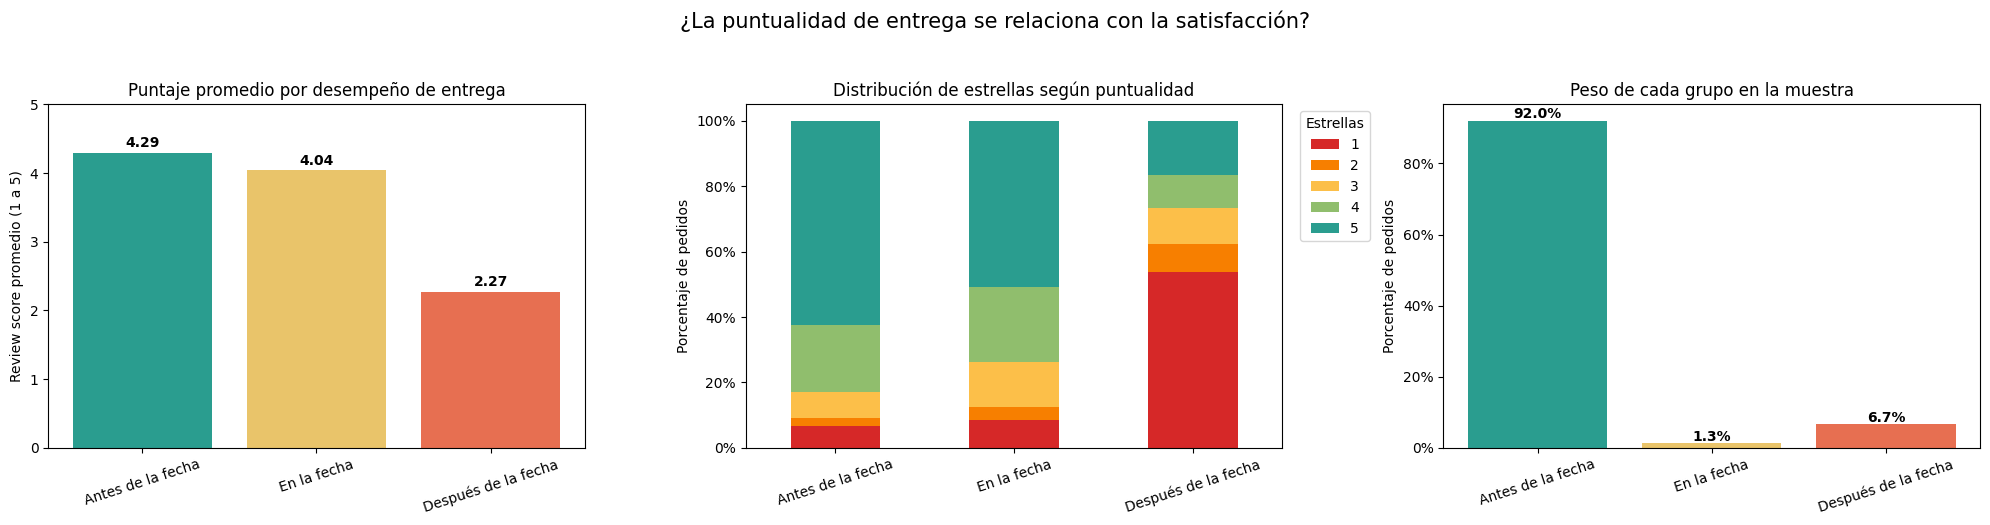

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Orden fijo para comparar las tres categorías de puntualidad
performance_order = [
    "Antes de la fecha",
    "En la fecha",
    "Después de la fecha"
]

# Resumen que alimenta los gráficos
summary = (
    analysis_table.groupby("delivery_performance")
    .agg(
        pedidos=("order_id", "nunique"),
        review_promedio=("review_score", "mean"),
        review_mediana=("review_score", "median"),
        porcentaje_1_estrella=("review_score", lambda s: (s.eq(1).mean() * 100))
    )
    .reindex(performance_order)
)
summary["porcentaje_muestra"] = summary["pedidos"] / len(analysis_table) * 100

display(summary.round(2))

# Distribución porcentual de estrellas dentro de cada grupo de entrega
rating_distribution = (
    pd.crosstab(
        analysis_table["delivery_performance"],
        analysis_table["review_score"],
        normalize="index"
    )
    .reindex(performance_order)
    .reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
)

# Participación de cada tipo de entrega en la muestra
performance_share = (
    analysis_table["delivery_performance"]
    .value_counts(normalize=True)
    .reindex(performance_order)
    * 100
)

colors = ["#2a9d8f", "#e9c46a", "#e76f51"]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: nota media
bars = axes[0].bar(performance_order, summary["review_promedio"], color=colors)
axes[0].set_title("Puntaje promedio por desempeño de entrega")
axes[0].set_ylabel("Review score promedio (1 a 5)")
axes[0].set_ylim(0, 5)
axes[0].tick_params(axis="x", rotation=18)
for bar, value in zip(bars, summary["review_promedio"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.08,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )

# Gráfico 2: composición de puntajes dentro de cada grupo
rating_distribution.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["#d62828", "#f77f00", "#fcbf49", "#90be6d", "#2a9d8f"]
)
axes[1].set_title("Distribución de estrellas según puntualidad")
axes[1].set_xlabel("")
axes[1].set_ylabel("Porcentaje de pedidos")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=18)
axes[1].legend(title="Estrellas", bbox_to_anchor=(1.02, 1), loc="upper left")

# Gráfico 3: tamaño de cada grupo, para interpretar los anteriores con contexto
bars = axes[2].bar(performance_order, performance_share, color=colors)
axes[2].set_title("Peso de cada grupo en la muestra")
axes[2].set_ylabel("Porcentaje de pedidos")
axes[2].yaxis.set_major_formatter(PercentFormatter(100))
axes[2].tick_params(axis="x", rotation=18)
for bar, value in zip(bars, performance_share):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.7,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

fig.suptitle("¿La puntualidad de entrega se relaciona con la satisfacción?", y=1.04, fontsize=15)
plt.tight_layout()
plt.show()

####1. ¿Los retrasos se relacionan con peores reseñas?
Sí, existe una asociación clara: los pedidos entregados después de la fecha estimada tienen un review_score promedio de 2,27, mientras que los entregados antes de la fecha promedian 4,29. Sin embargo, el análisis no demuestra que el retraso sea la única causa de una mala reseña.
####2. Reseñas.
*   La mayoría de los pedidos tiene una reseña. Hay 543 pedidos con dos filas de reseña y 4 con tres. Como no se sabe con certeza qué representan esas filas adicionales, ya que podría ser reseñas repetidas, modificadas o una nueva reseña añadida, esto es una hipotesis, no significa que podría ser eso.
*   El análisis principal usa pedidos con una sola reseña original para evitar que un promedio de varias filas se interprete como una nota real.

####3. Gráficos
De los 3 gráficos, el más representativo es el segundo, en donde indica que el mayor porcentaje de mejores puntuaciones son antes de la fecha de entrega, aún así hay clientes que han dado 1 estrella, se podría inferir que es porque el articulo llegó en mal estado o fue otro articulo distinto al que el cliente pidió, esto solo sería una posibilidad, no es demostrable.
####4. Conclusión
Los pedidos que llegan tarde se asocian con peores reseñas. Los pedidos entregados antes o en la fecha estimada tienden a recibir puntajes más altos, aunque factores como estado del producto, vendedor o experiencia de compra también pueden afectar la satisfacción.
